<a href="https://colab.research.google.com/github/kevinquiosc-rgb/Projectos_Kevin/blob/main/Proyecto_final_de_curso_Demanda_de_Ventas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROYECTO FINAL DE PROYECCION DE DEMANDA DE VENTAS

El presente NOTEBOOK es un proyecto final de curso de analisis de series temporales, se realizo un analisis completo para estimar la demanda de ventas de una empresa con multiples tiendas, con mas de 913 mil registros por tienda un ejemplo de BIG DATA y series temporales.

Se realizó un proceso completo de analisis estadistico pasando por enfocar un analisis centrado en una sola tienda y uno de los 28 productos disponibles, realizando

1. Proceso de carga de datos ETL
2. Analisis Exploratorio de datos
3. Analisis de series temporales
6. Ajuste y Comparacion de modelos TRIPLE SUAV EXP - Trans Log - ARIMA
7. Presentacion del mejor modelo

1. El proceso ETL consistió en cargar la base que tenia un tipo de encodificacion, formato CSV separados con punto y coma, ademas existen columnas vacias que fueron retiradas, tambien se cambio el tipo de dato numero a ENTERO para evitar errores y se etiquetaron los datos, dentro de las 10 tiendas se escogio la tienda 2 y de los productos a proyectar se escogió el producto nro 28 se indexaron y acumularon las ventas por MES la cual comprende el periodo del año 2013 al 2017.

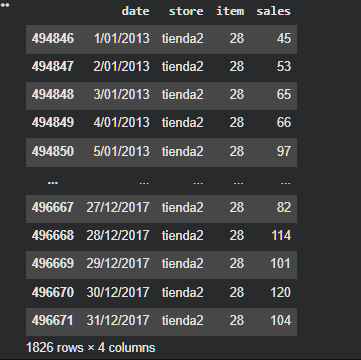

2. El analisis exploratorio grafico muestra una tendencia ascendente y una estacionalidad marcada idoneos para el analisis de series temporales, ademas tambien muestra una distribucion normal a lo largo de los meses.

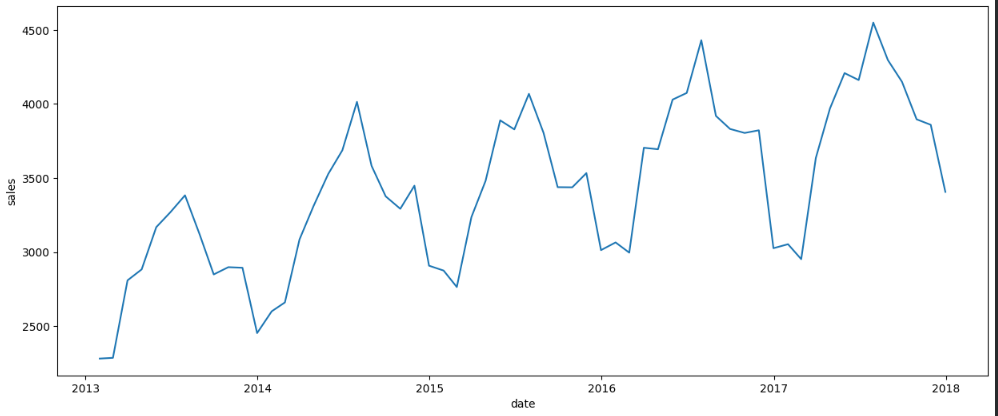

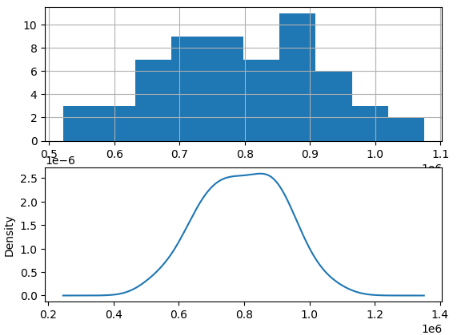

3. El analisis de series temporales confirma la tendencia y la estacionalidad  que junto con la normalidad y dickey/fuller(prueba de estacionariedad)  y eso nos da pie a realizar modelos clasicos como ARIMA.

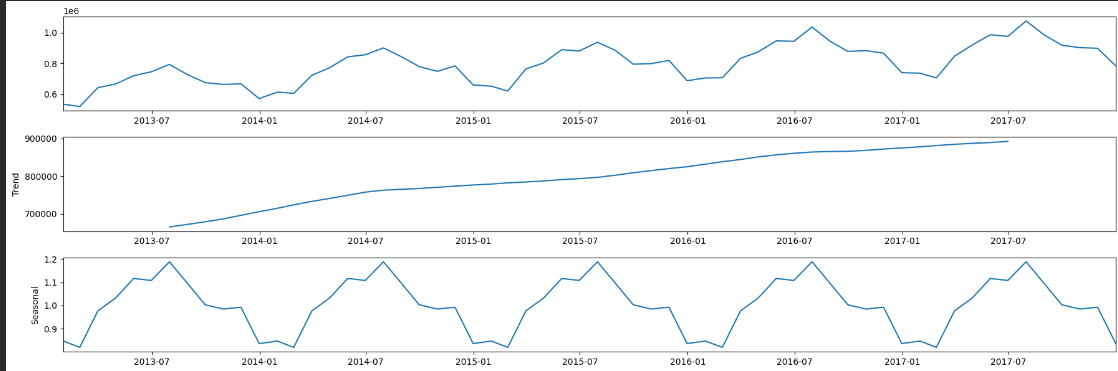

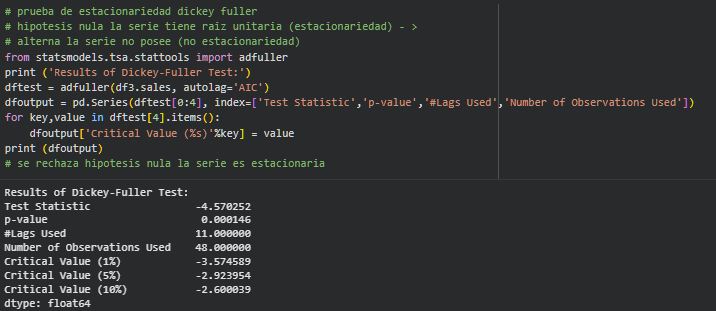

4. En el ajuste de modelos se estimaron los ajustes de los modelos TRIPLE SUAV EXP, HOLT WINTERS Y ARIMA.

PROPHET

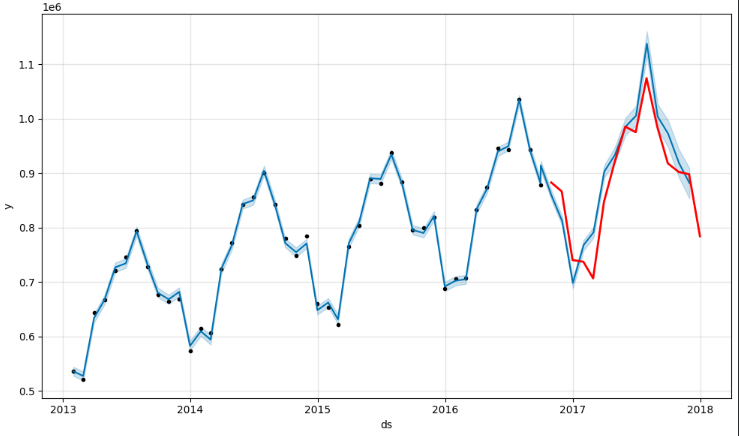

TRIPLE SUAVIZADO EXPONENCIAL

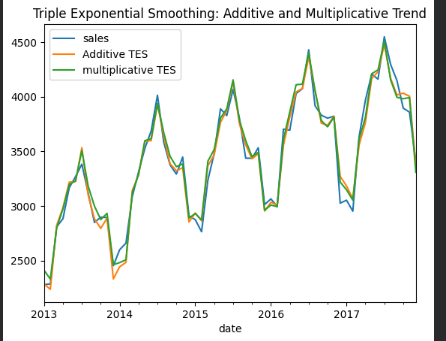

HOLT WINTERS

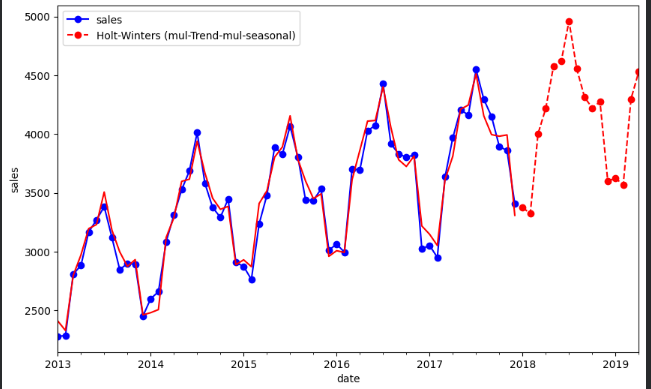

ARIMA

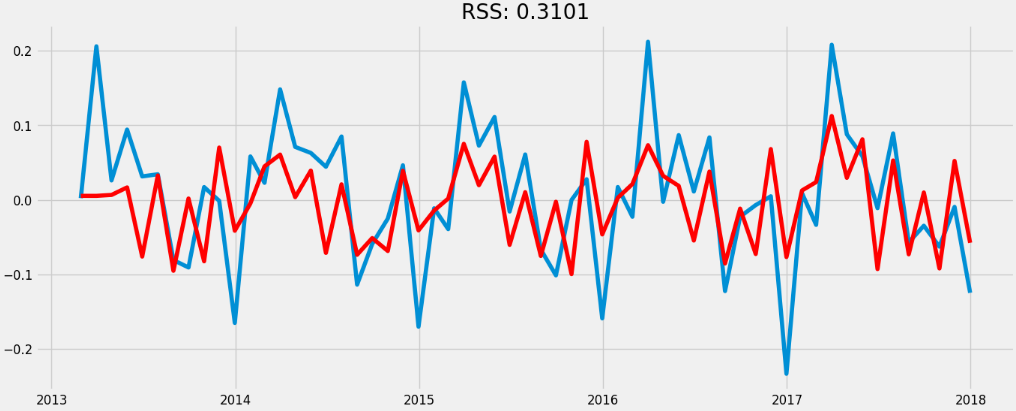

5. MERICAS DE BONDAD DE AJUSTE - EL EJOR MODELOFUE EL SUAVIZADO EXP ADIIVO Y MULTIPLICATIVO

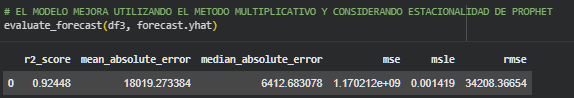

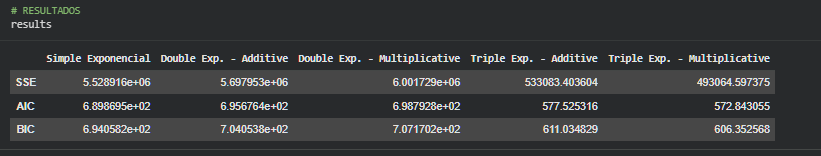

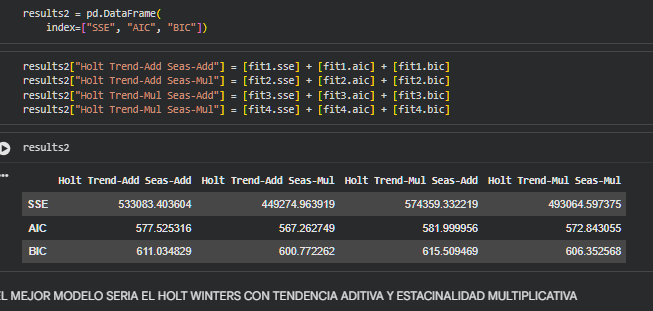

# Proceso de ETL

In [ ]:
## CARGA DE CSV EN DF
df = pd.read_csv('/content/drive/MyDrive/SERIES TEMPORALES/SalesDemand-examen.csv',encoding='latin-1', sep = ';')

In [ ]:
# COLUMNAS DF
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958000 entries, 0 to 957999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    913000 non-null  object 
 1   store   913000 non-null  float64
 2   item    913000 non-null  float64
 3   sales   913000 non-null  float64
dtypes: float64(3), object(1)
memory usage: 29.2+ MB


In [ ]:
# PRIMERA VISTA DF
df.head()

,date,store,item,sales
0,1/01/2013,1.0,1.0,13.0
1,2/01/2013,1.0,1.0,11.0
2,3/01/2013,1.0,1.0,14.0
3,4/01/2013,1.0,1.0,13.0
4,5/01/2013,1.0,1.0,10.0


In [ ]:
# COLA DF
df.tail()

,date,store,item,sales
957995,NaN,NaN,NaN,NaN
957996,NaN,NaN,NaN,NaN
957997,NaN,NaN,NaN,NaN
957998,NaN,NaN,NaN,NaN
957999,NaN,NaN,NaN,NaN


In [ ]:
# proporcion de store en sales para seleccionar1 - escojo el 8
df.groupby('store')['sales'].sum() / df['sales'].sum()

store
1.0     0.090465
2.0     0.128292
3.0     0.113934
4.0     0.105077
5.0     0.076115
6.0     0.076045
7.0     0.069595
8.0     0.122759
9.0     0.105356
10.0    0.112362
Name: sales, dtype: float64

In [ ]:
# proporcion de productos para seleccionar 1 - escojo el 28
df.groupby('item')['sales'].sum() / df['sales'].sum()

item
1.0     0.008414
2.0     0.022421
3.0     0.014026
4.0     0.008425
5.0     0.007027
6.0     0.022394
7.0     0.022404
8.0     0.029454
9.0     0.019671
10.0    0.028029
11.0    0.026663
12.0    0.026654
13.0    0.032274
14.0    0.022462
15.0    0.033696
16.0    0.009820
17.0    0.012630
18.0    0.032258
19.0    0.015447
20.0    0.018188
21.0    0.015432
22.0    0.030814
23.0    0.011214
24.0    0.025280
25.0    0.030885
26.0    0.018237
27.0    0.008440
28.0    0.033639
29.0    0.026648
30.0    0.015440
31.0    0.022447
32.0    0.016835
33.0    0.026626
34.0    0.009851
35.0    0.025187
36.0    0.029485
37.0    0.011199
38.0    0.030822
39.0    0.016797
40.0    0.011196
41.0    0.008422
42.0    0.014043
43.0    0.019634
44.0    0.011253
45.0    0.030845
46.0    0.022446
47.0    0.008422
48.0    0.019656
49.0    0.011229
50.0    0.025218
Name: sales, dtype: float64

In [ ]:
# CONTAR NAN
df.value_counts(dropna=False)

date        store  item  sales
1/01/2013   1.0    1.0   13.0     1
28/04/2015  4.0    21.0  39.0     1
                   10.0  73.0     1
                   11.0  74.0     1
                   12.0  87.0     1
                                 ..
19/02/2016  7.0    38.0  57.0     1
                   39.0  33.0     1
                   40.0  12.0     1
                   41.0  19.0     1
9/12/2017   10.0   50.0  69.0     1
Length: 913000, dtype: int64

In [ ]:
# LIMPIAR NA EN DF
df = df.dropna(how='all')
df.value_counts(dropna=False)

date        store  item  sales
1/01/2013   1.0    1.0   13.0     1
28/04/2015  4.0    21.0  39.0     1
                   10.0  73.0     1
                   11.0  74.0     1
                   12.0  87.0     1
                                 ..
19/02/2016  7.0    38.0  57.0     1
                   39.0  33.0     1
                   40.0  12.0     1
                   41.0  19.0     1
9/12/2017   10.0   50.0  69.0     1
Length: 913000, dtype: int64

In [ ]:
# % DE STORES
df['store'].value_counts()/df['store'].value_counts().sum()

1.0     0.1
2.0     0.1
3.0     0.1
4.0     0.1
5.0     0.1
6.0     0.1
7.0     0.1
8.0     0.1
9.0     0.1
10.0    0.1
Name: store, dtype: float64

In [ ]:
# TOTAL DE STORES
df.store.value_counts(dropna=False)

1.0     91300
2.0     91300
3.0     91300
4.0     91300
5.0     91300
6.0     91300
7.0     91300
8.0     91300
9.0     91300
10.0    91300
Name: store, dtype: int64

In [ ]:
## TRANSFORMAR STORE EN TXT
df['store'] = df['store'].replace([1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0],
 ["tienda1","tienda2","tienda3","tienda4","tienda5","tienda6","tienda7","tienda8","tienda9","tienda10"])

In [ ]:
# % DE STORES escojo la tienda 8 para analizar
df.groupby('store')['sales'].sum() / df['sales'].sum()

store
tienda1     0.090465
tienda10    0.112362
tienda2     0.128292
tienda3     0.113934
tienda4     0.105077
tienda5     0.076115
tienda6     0.076045
tienda7     0.069595
tienda8     0.122759
tienda9     0.105356
Name: sales, dtype: float64

In [ ]:
# VALIDACION DE NA
df.value_counts(dropna=False)

date        store    item  sales
1/01/2013   tienda1  1.0   13.0     1
28/04/2015  tienda3  21.0  43.0     1
                     10.0  65.0     1
                     11.0  82.0     1
                     12.0  79.0     1
                                   ..
19/02/2016  tienda6  38.0  46.0     1
                     39.0  30.0     1
                     40.0  17.0     1
                     41.0  12.0     1
9/12/2017   tienda9  50.0  68.0     1
Length: 913000, dtype: int64

In [ ]:
df.tail()

,date,store,item,sales
912995,27/12/2017,tienda10,50.0,63.0
912996,28/12/2017,tienda10,50.0,59.0
912997,29/12/2017,tienda10,50.0,74.0
912998,30/12/2017,tienda10,50.0,62.0
912999,31/12/2017,tienda10,50.0,82.0


In [ ]:
# VALIDAR LIMPIEZA
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    913000 non-null  object 
 1   store   913000 non-null  object 
 2   item    913000 non-null  float64
 3   sales   913000 non-null  float64
dtypes: float64(2), object(2)
memory usage: 34.8+ MB


In [ ]:
# PERIODO INICIO A FIN
print('Inicio de periodo: {}\nPeriodo Final: {}'.format(df.date.min(),df.date.max()))

Inicio de periodo: 1/01/2013
Periodo Final: 9/12/2017


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  object        
 2   item    913000 non-null  float64       
 3   sales   913000 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 34.8+ MB


In [ ]:
df.value_counts(dropna=False)

date        store    item  sales
2013-01-01  tienda1  1.0   13.0     1
2016-05-02  tienda3  21.0  40.0     1
                     10.0  77.0     1
                     11.0  88.0     1
                     12.0  76.0     1
                                   ..
2014-09-01  tienda6  38.0  39.0     1
                     39.0  29.0     1
                     40.0  12.0     1
                     41.0  10.0     1
2017-12-31  tienda9  50.0  65.0     1
Length: 913000, dtype: int64

In [ ]:
# CAMBIO DE TIPO DE ITEM Y SALES
df['item'] = df['item'].astype(int)
df['sales'] = df['sales'].astype(int)

In [ ]:
# VALIDACION DE TIPO
df.dtypes

date     object
store    object
item      int64
sales     int64
dtype: object

In [ ]:
# SEPARANDO DF A TRABAJAR, TIENDA 2 Y PRODUCTO 28 EN OTRO DATAFRAME
df1 = df[(df['store'] == 'tienda2') & (df['item'] ==28)]
df1

,date,store,item,sales
494846,1/01/2013,tienda2,28,45
494847,2/01/2013,tienda2,28,53
494848,3/01/2013,tienda2,28,65
494849,4/01/2013,tienda2,28,66
494850,5/01/2013,tienda2,28,97
...,...,...,...,...
496667,27/12/2017,tienda2,28,82
496668,28/12/2017,tienda2,28,114
496669,29/12/2017,tienda2,28,101
496670,30/12/2017,tienda2,28,120


In [ ]:
##retirando columna item (que ya definimos como producto nro 28 y tienda2)
df2 = df1[['date','sales']]
df2

,date,sales
494846,1/01/2013,45
494847,2/01/2013,53
494848,3/01/2013,65
494849,4/01/2013,66
494850,5/01/2013,97
...,...,...
496667,27/12/2017,82
496668,28/12/2017,114
496669,29/12/2017,101
496670,30/12/2017,120


In [ ]:
# SETEANDO FECHAS A INDEX
df2.set_index('date', inplace=True)
df2.index = pd.to_datetime(df2.index)

In [ ]:
# RESAMPLEANDO A DATA MENSUAL ACUMULANDO VENTAS
df3 = df2.resample('M').sum()

In [ ]:
# VALIDANDO SAMPLEADO
df3

,sales
date,
2013-01-31,2281
2013-02-28,2286
2013-03-31,2809
2013-04-30,2883
2013-05-31,3168
2013-06-30,3269
2013-07-31,3383
2013-08-31,3120
2013-09-30,2849


# ANALISIS EXPLORATORIO

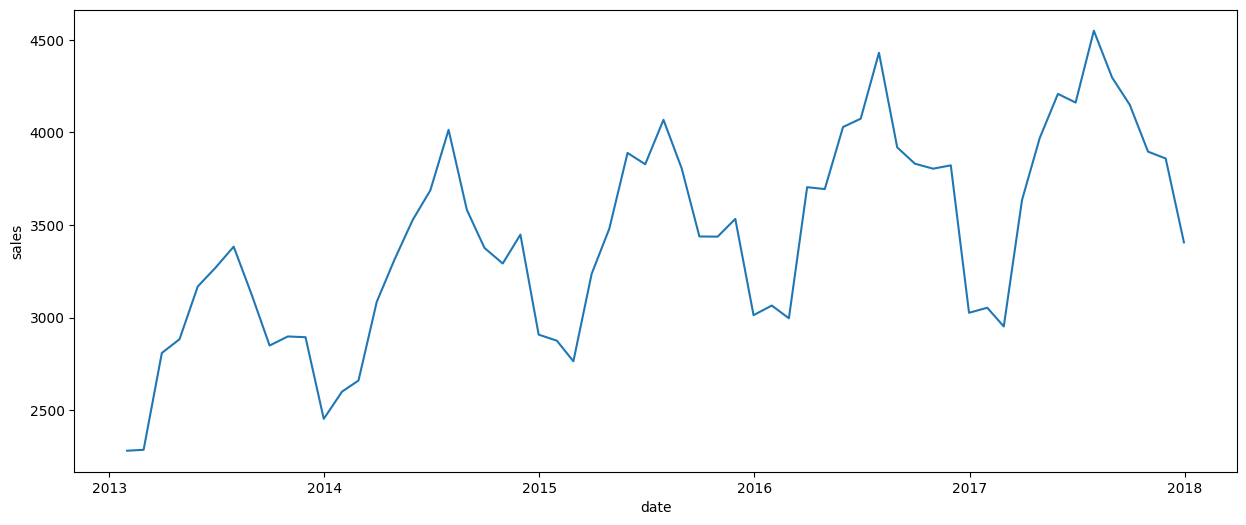

In [ ]:
# Visualizando datos completos mensuales (ventas mensuales de la tienda 2 producto 28)
fig, ax = plt.subplots(figsize=(15,6))
sns.lineplot(x = df3.index, y= df3.sales, ax=ax)
pyplot.show()

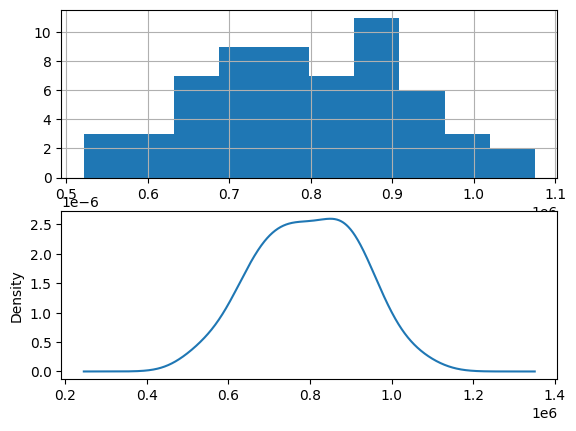

In [ ]:
# HISTOGRAMA Y DENSIDAD - habria normalidad
pyplot.figure(1)
pyplot.subplot(211)
df3.sales.hist()
pyplot.subplot(212)
df3.sales.plot(kind='kde')
pyplot.show()

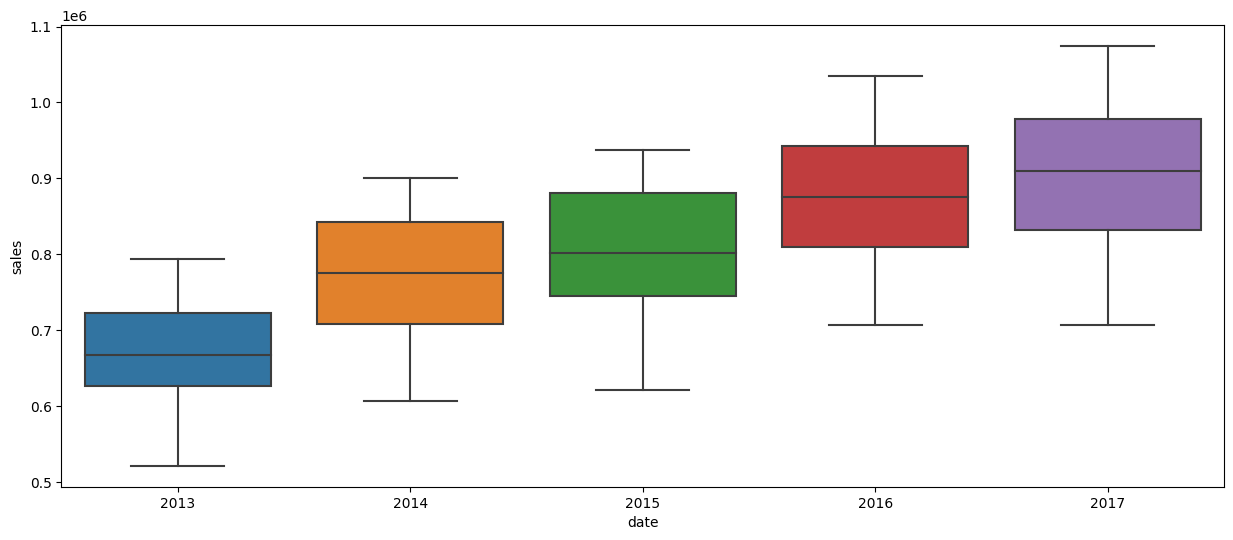

In [ ]:
# CAJAS Y BIGOTES
fig, ax = plt.subplots(figsize=(15,6))
sns.boxplot(x= df3.index.year,y= df3.sales, ax=ax)
pyplot.show()

# ANALISIS DE SERIES TEMPORALES

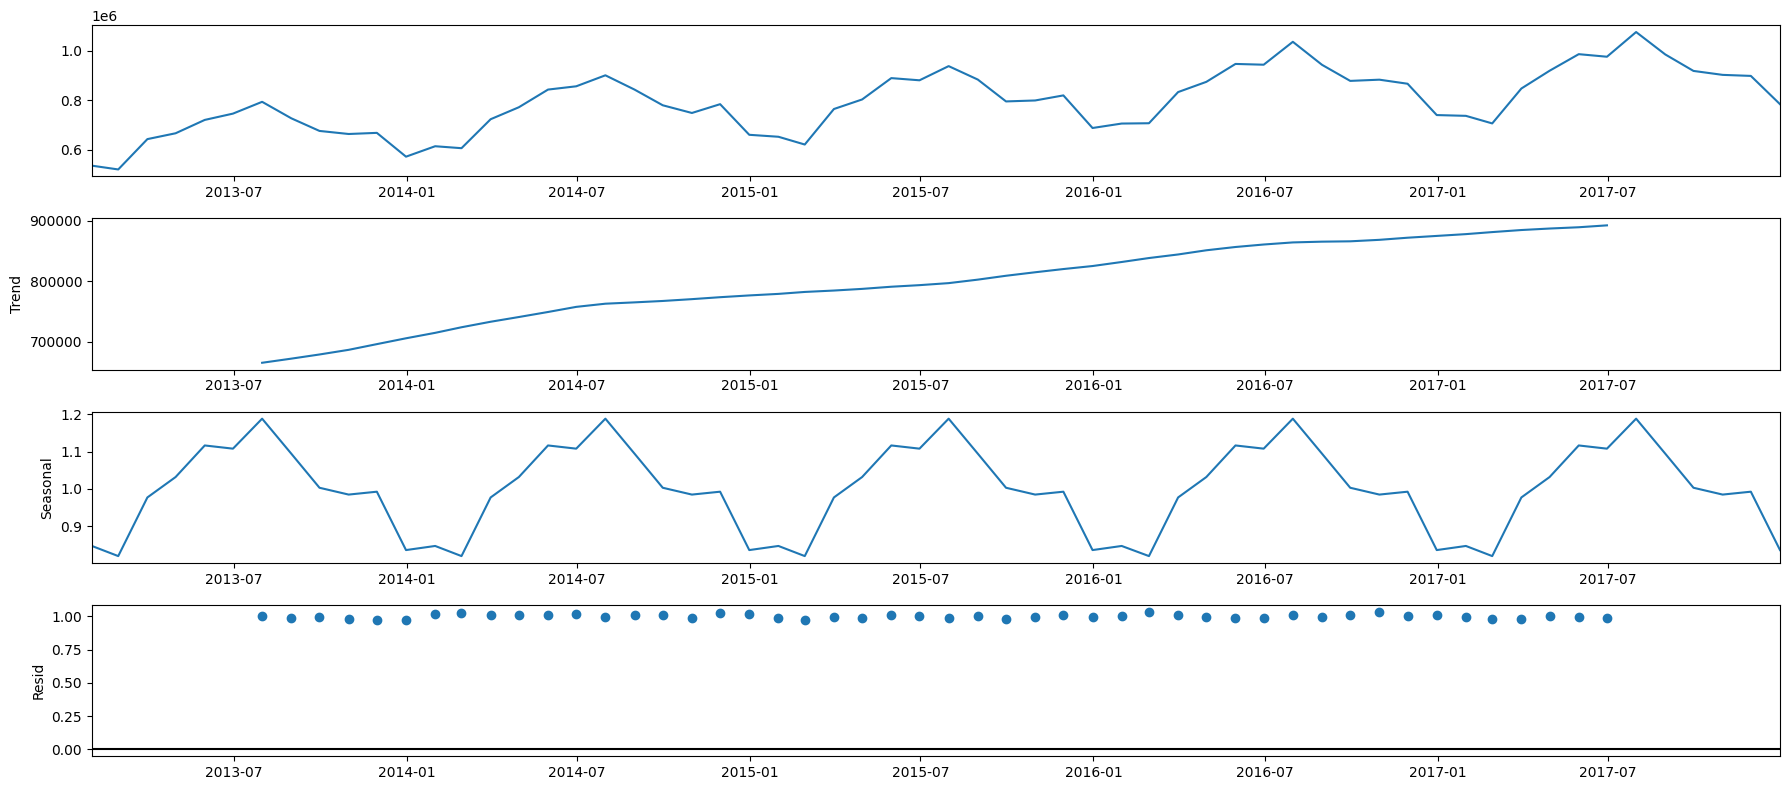

In [ ]:
# DESCOMPOSICION CLASICA DE LA SERIE
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib
decomposition = sm.tsa.seasonal_decompose(df3, model='multiplicative')
matplotlib.rcParams['figure.figsize'] = 18, 8
fig = decomposition.plot()
plt.show()

In [ ]:
## SE EVIDENCIA TENDENCIA Y ESTACIONALIDAD

<Axes: xlabel='date'>

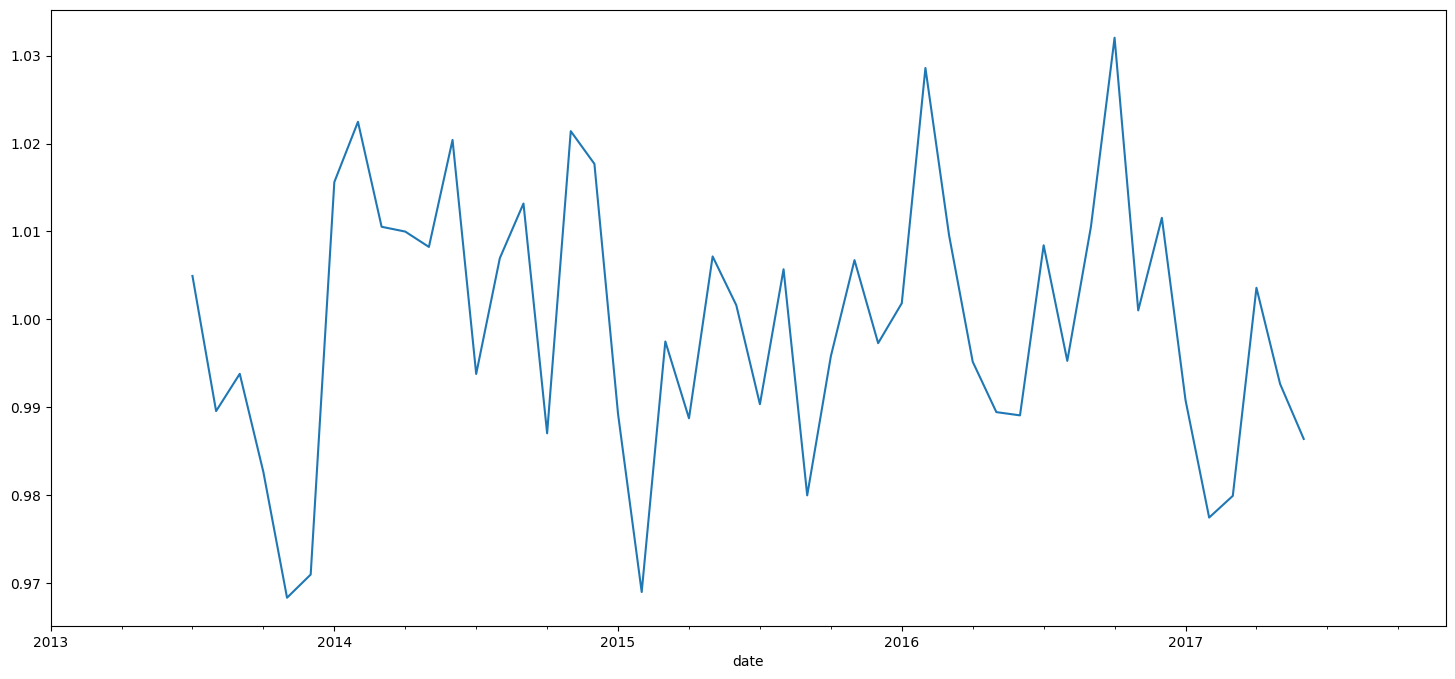

In [ ]:
## RESIDUALES
decomposition.resid.plot()

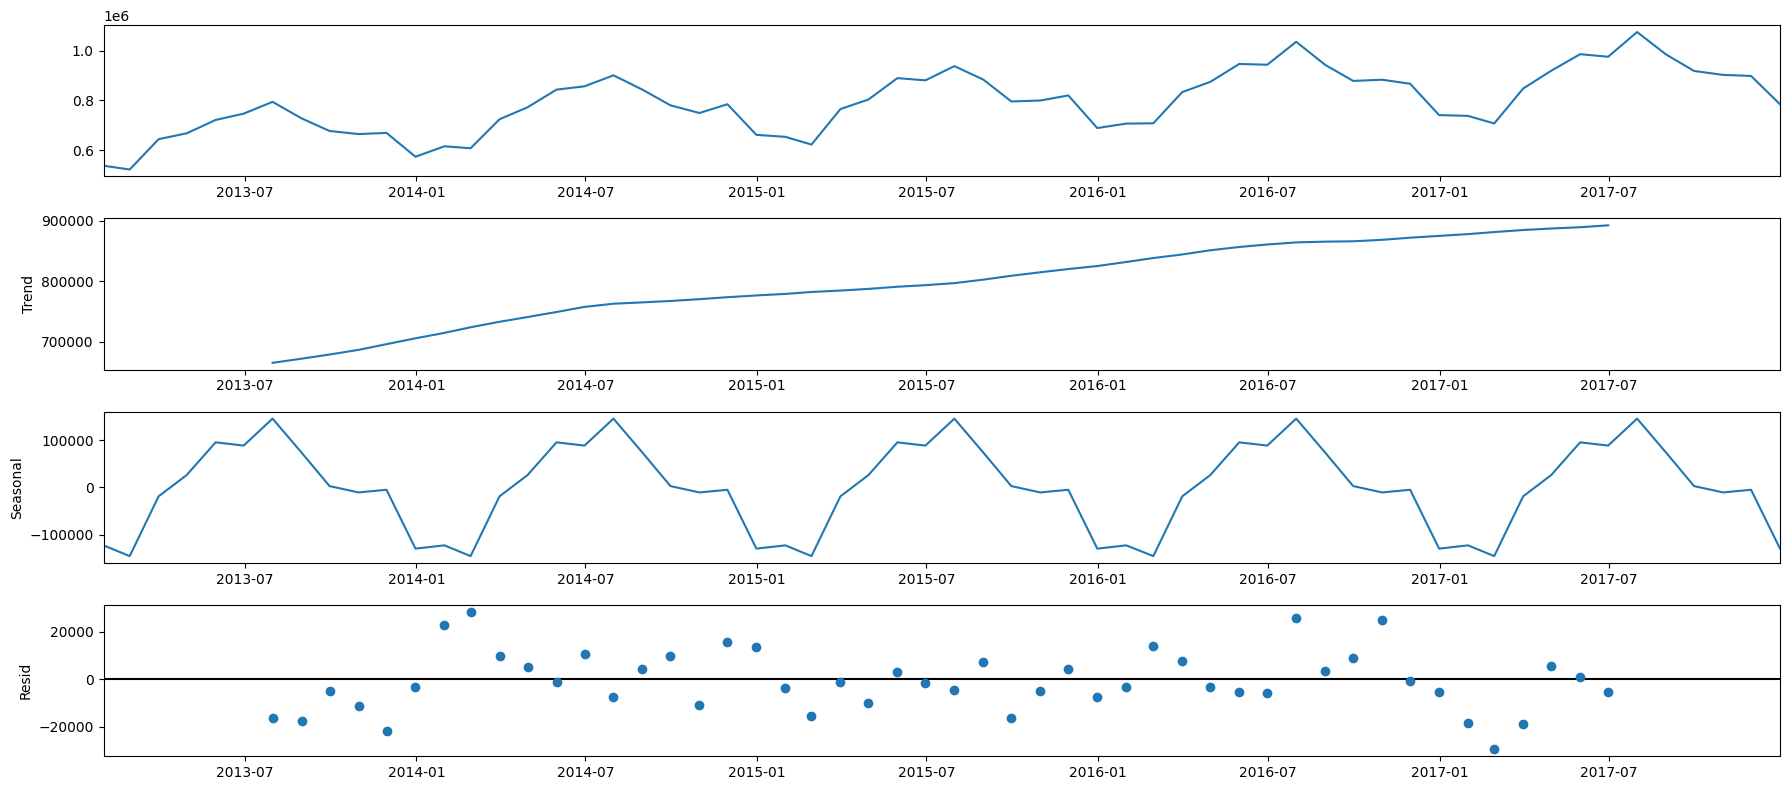

In [ ]:
# OBSERVANDO EL MODELO ADITIVO
from pylab import rcParams
matplotlib.rcParams['figure.figsize'] = 18, 8
decomposition = sm.tsa.seasonal_decompose(df3, model='aditive')
fig = decomposition.plot()
plt.show()

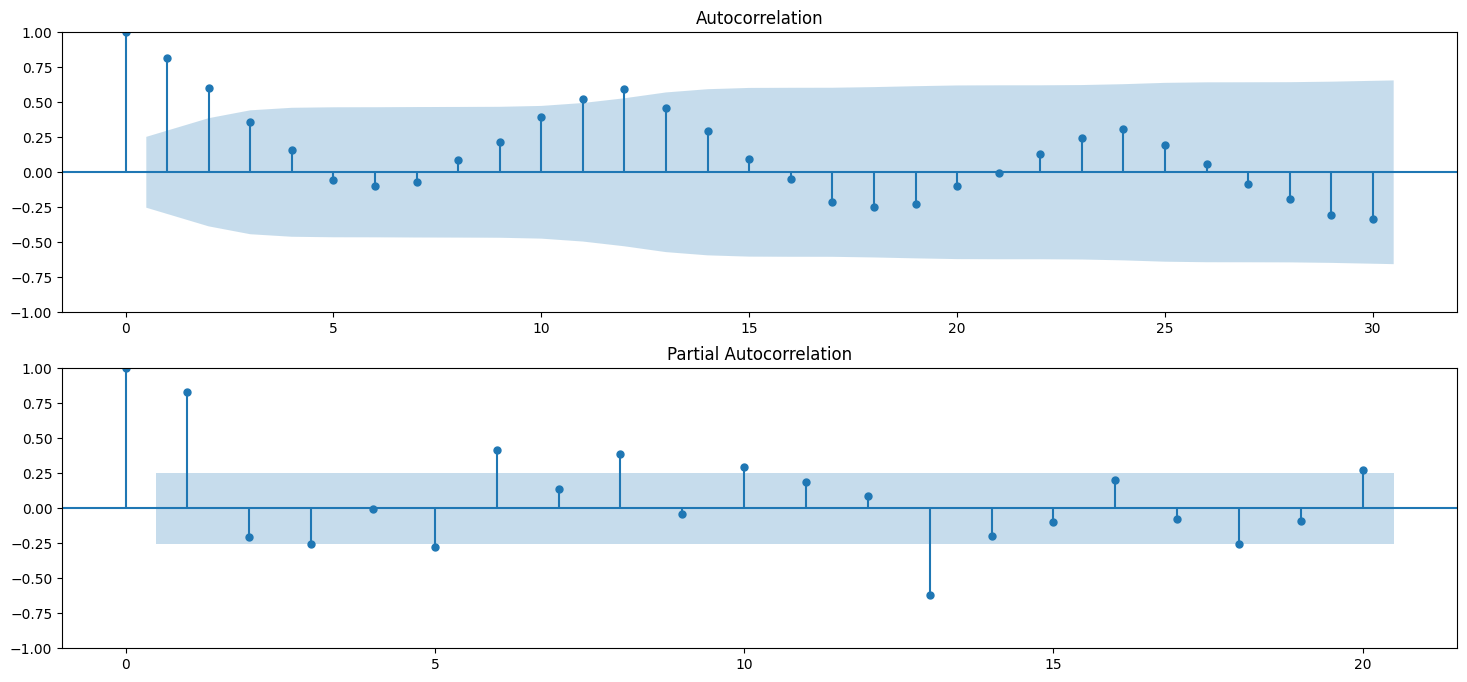

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

pyplot.figure()
pyplot.subplot(211)
plot_acf(df3.sales, ax=pyplot.gca(), lags = 30)
pyplot.subplot(212)
plot_pacf(df3.sales, ax=pyplot.gca(), lags = 20)
pyplot.show()

In [ ]:
# prueba de estacionariedad dickey fuller
# hipotesis nula la serie tiene raiz unitaria (estacionariedad) - >
# alterna la serie no posee (no estacionariedad)
from statsmodels.tsa.stattools import adfuller
print ('Results of Dickey-Fuller Test:')
dftest = adfuller(df3.sales, autolag='AIC')
dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
print (dfoutput)
# se rechaza hipotesis nula la serie es estacionaria

Results of Dickey-Fuller Test:
Test Statistic                 -4.570252
p-value                         0.000146
#Lags Used                     11.000000
Number of Observations Used    48.000000
Critical Value (1%)            -3.574589
Critical Value (5%)            -2.923954
Critical Value (10%)           -2.600039
dtype: float64


##  MODELO DE PRONOSTICO PROPHET

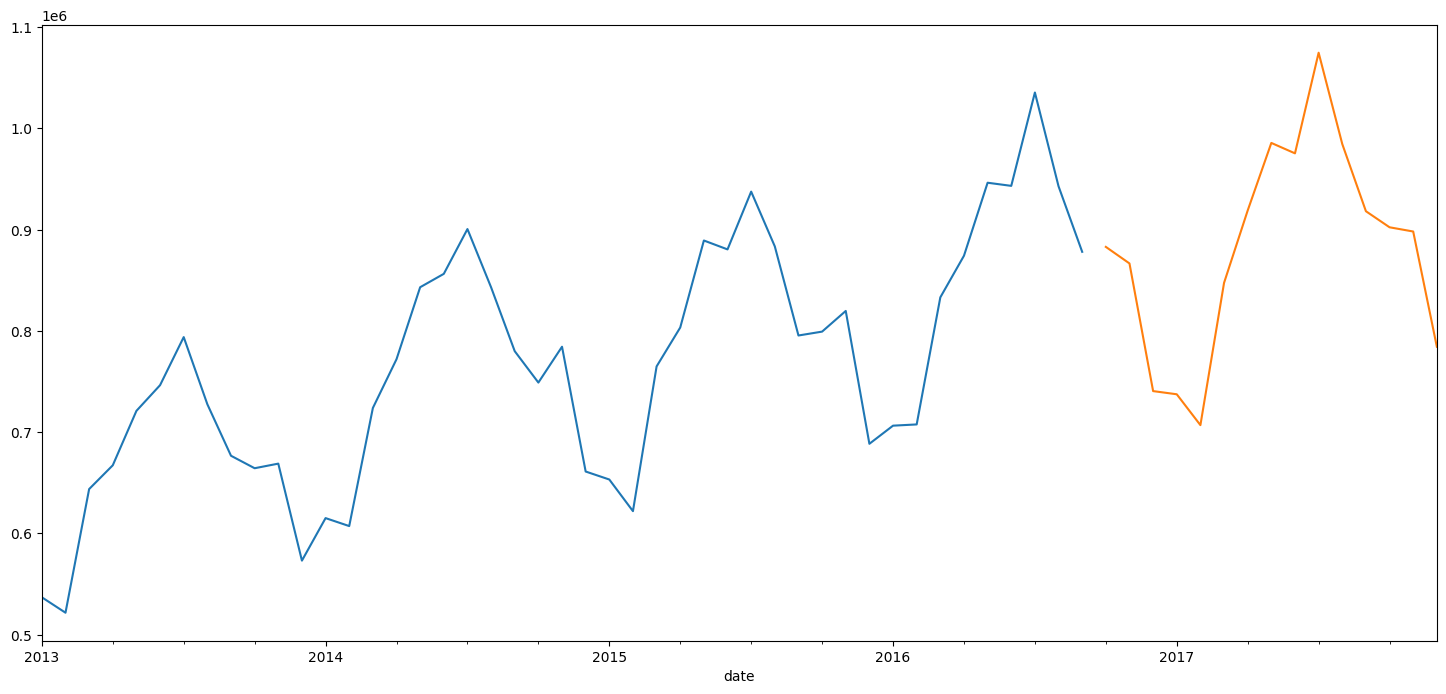

In [ ]:
#divide into train and validation set
train = df3[:int(0.75*(len(df3)))]
valid = df3[int(0.75*(len(df3))):]

#plotting the data
train['sales'].plot()
valid['sales'].plot()
plt.show()

In [ ]:
print(train.shape)
print(valid.shape)

(45, 1)
(15, 1)


In [ ]:
train_prophet = pd.DataFrame()
train_prophet['ds'] = train.index
train_prophet['y'] = train.sales.values

In [ ]:
train_prophet.head()

,ds,y
0,2013-01-31,536883
1,2013-02-28,521637
2,2013-03-31,643749
3,2013-04-30,667252
4,2013-05-31,720997


In [ ]:
## IMPORTAR PROPHET
from prophet import Prophet

In [ ]:
#instantiate Prophet with only yearly seasonality as our data is monthly
model = Prophet()
model.fit(train_prophet) #fit the model with your dataframe

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdod316qs/q66ne1l2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdod316qs/wnnjy95y.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=69182', 'data', 'file=/tmp/tmpdod316qs/q66ne1l2.json', 'init=/tmp/tmpdod316qs/wnnjy95y.json', 'output', 'file=/tmp/tmpdod316qs/prophet_model9ewvxdo4/prophet_model-20230629060229.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
06:02:29 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:02:30 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
# predict for five months in the furure and MS - month start is the frequency
future = model.make_future_dataframe(periods = 15, freq = 'MS')
future

,ds
0,2013-01-31
1,2013-02-28
2,2013-03-31
3,2013-04-30
4,2013-05-31
5,2013-06-30
6,2013-07-31
7,2013-08-31
8,2013-09-30
9,2013-10-31


In [ ]:
# now lets make the forecasts
forecast = model.predict(future)
forecast[['ds', 'yhat']]

,ds,yhat
0,2013-01-31,5.359145e+05
1,2013-02-28,5.134414e+05
2,2013-03-31,6.349372e+05
3,2013-04-30,6.692978e+05
4,2013-05-31,7.349884e+05
5,2013-06-30,7.412849e+05
6,2013-07-31,8.047718e+05
7,2013-08-31,7.351129e+05
8,2013-09-30,6.764707e+05
9,2013-10-31,6.660128e+05


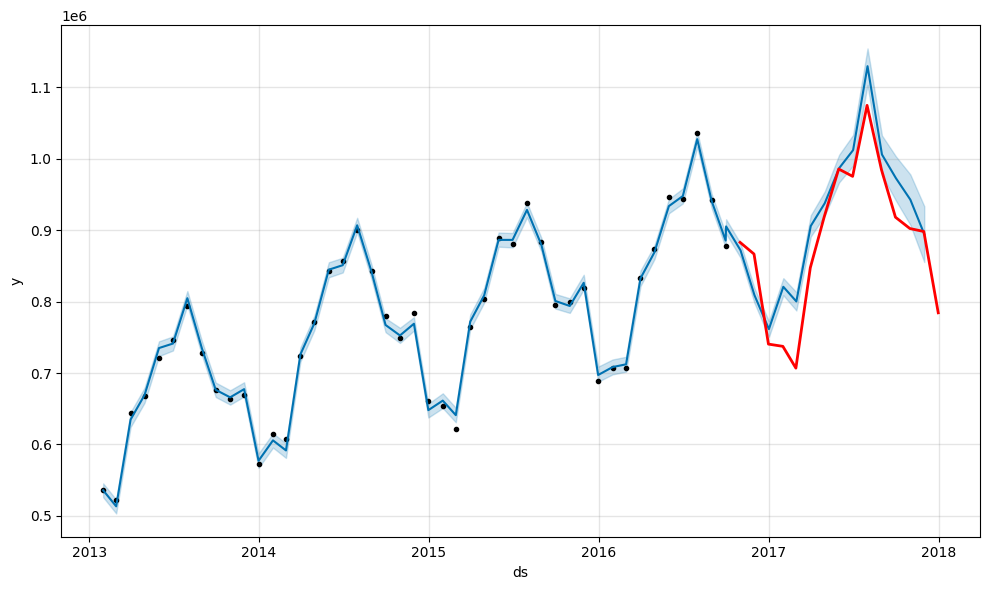

In [ ]:
fig = model.plot(forecast)
#plot the predictions for validation set

plt.plot(valid, label='Valid', color = 'red', linewidth = 2)

plt.show()

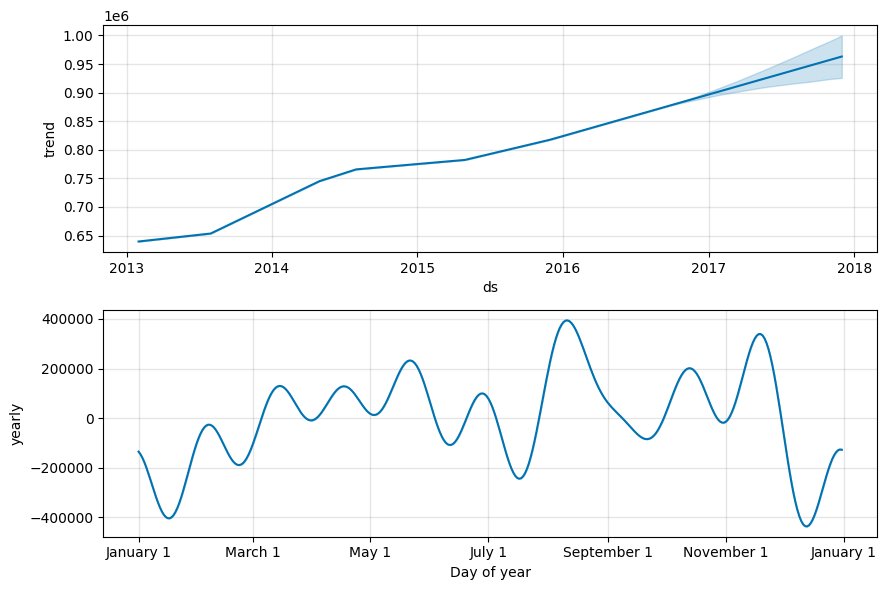

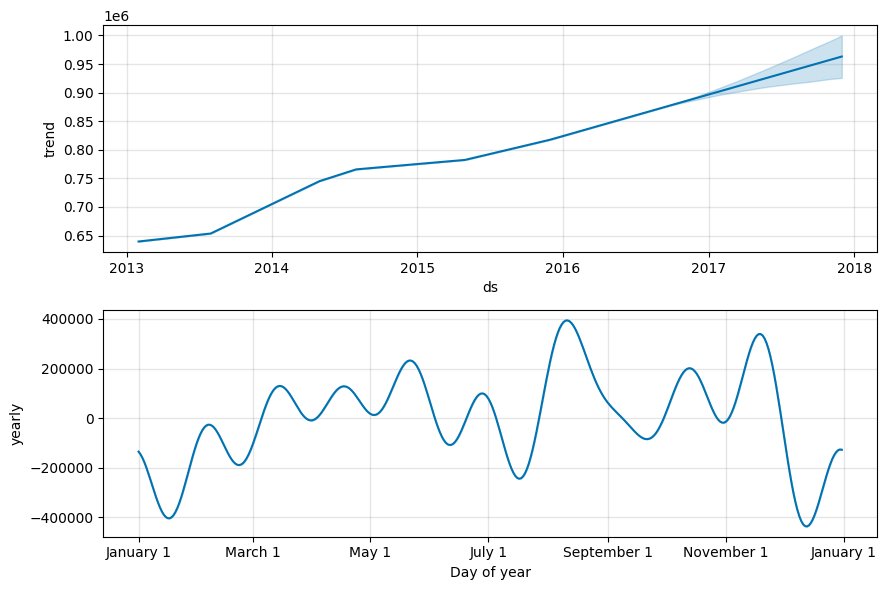

In [ ]:
# COMPONENTES
model.plot_components(forecast)

In [ ]:
# CARGANDO MEDIDAS
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error, mean_squared_log_error

In [ ]:
def evaluate_forecast(df3,pred):
    results = pd.DataFrame({'r2_score':r2_score(df3, pred),
                           }, index=[0])
    results['mean_absolute_error'] = mean_absolute_error(df3, pred)
    results['median_absolute_error'] = median_absolute_error(df3, pred)
    results['mse'] = mean_squared_error(df3, pred)
    results['msle'] = mean_squared_log_error(df3, pred)
    results['rmse'] = np.sqrt(results['mse'])
    return results

In [ ]:
# EVALUACION DE METRICAS DE BONDAD DE AJUSTE
evaluate_forecast(df3, forecast.yhat)

,r2_score,mean_absolute_error,median_absolute_error,mse,msle,rmse
0,0.915969,19500.527245,7805.169432,1.302095e+09,0.00166,36084.558903


In [ ]:
#definiendo que la estacionalidad sea anual y el modelo multiplicativo
model = Prophet(yearly_seasonality=True,seasonality_mode= 'multiplicative')
model.fit(train_prophet) #fit the model with your dataframe

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdod316qs/_kdyt768.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdod316qs/yr2atb5r.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=35560', 'data', 'file=/tmp/tmpdod316qs/_kdyt768.json', 'init=/tmp/tmpdod316qs/yr2atb5r.json', 'output', 'file=/tmp/tmpdod316qs/prophet_modela57idqfn/prophet_model-20230629061645.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
06:16:45 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:16:45 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


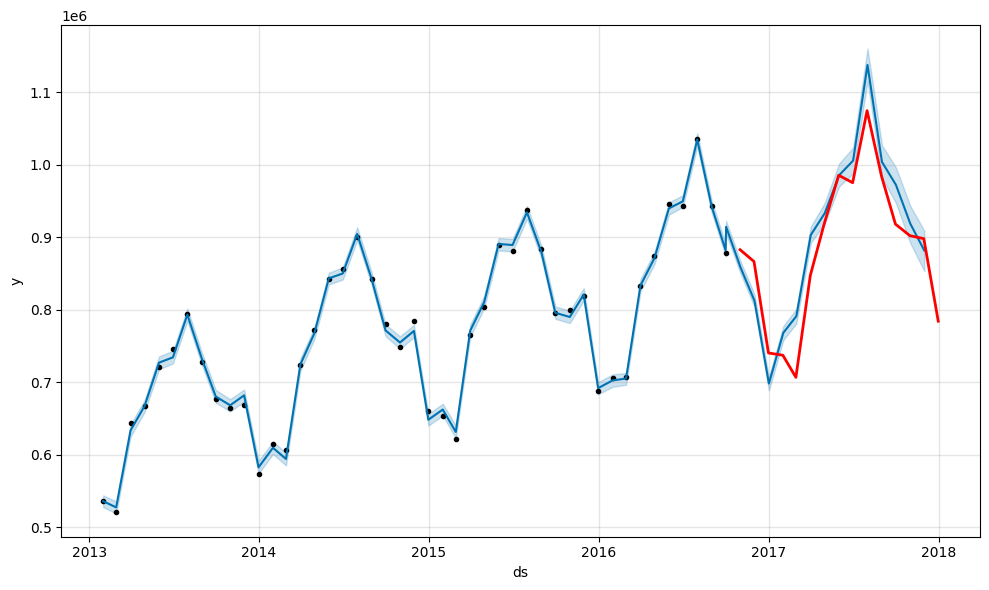

In [ ]:
# predict for five months in the furure and MS - month start is the frequency
future = model.make_future_dataframe(periods = 15, freq = 'MS')
forecast = model.predict(future)
fig = model.plot(forecast)
#plot the predictions for validation set

plt.plot(valid, label='Valid', color = 'red', linewidth = 2)

plt.show()

In [ ]:
# EL MODELO MEJORA UTILIZANDO EL METODO MULTIPLICATIVO Y CONSIDERANDO ESTACIONALIDAD DE PROPHET
evaluate_forecast(df3, forecast.yhat)

,r2_score,mean_absolute_error,median_absolute_error,mse,msle,rmse
0,0.92448,18019.273384,6412.683078,1.170212e+09,0.001419,34208.36654


## TECNICAS DE SUAVIZACION EXPONENCIAL

In [ ]:
# CARGA DE LIBRERIAAS
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
import matplotlib.pyplot as plt

<Axes: title={'center': 'Single Exponential Smoothing'}, xlabel='date'>

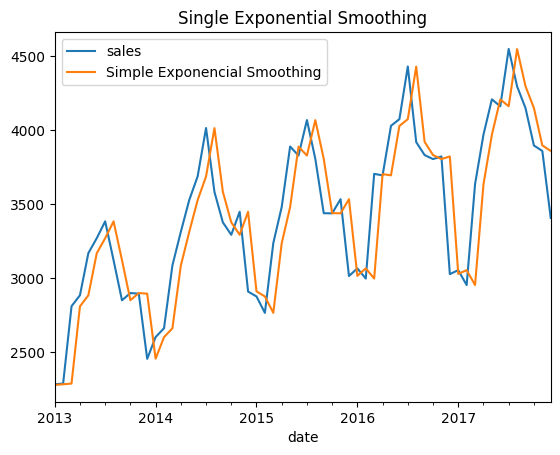

In [ ]:
# SUAVIZADO EXPONENCIAL SIMPLE
HWES1 = SimpleExpSmoothing(df3, initialization_method="estimated").fit()
HWES1_fitted = HWES1.fittedvalues
HWES1_fitted.name = 'Simple Exponencial Smoothing'
pd.concat([df3, HWES1_fitted], axis=1).plot(title='Single Exponential Smoothing')

In [ ]:
# RESULTADOS DE BONDAD DE AJUSTE
results = pd.DataFrame(
    index=["SSE", "AIC", "BIC"])
results["Simple Exponencial"] = [HWES1.sse] + [HWES1.aic] + [HWES1.bic]

In [ ]:
# MEDIDAS DE BONDAD DE AJUSTE A COMPARAR CON EL RESTO DE MODELOS
print(HWES1.summary())

                       SimpleExpSmoothing Model Results                       
Dep. Variable:                  sales   No. Observations:                   60
Model:             SimpleExpSmoothing   SSE                        5528915.550
Optimized:                       True   AIC                            689.869
Trend:                           None   BIC                            694.058
Seasonal:                        None   AICC                           690.597
Seasonal Periods:                None   Date:                 Fri, 30 Jun 2023
Box-Cox:                        False   Time:                         01:19:50
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.9975559                alpha                 True
initial_level              2276.7385                

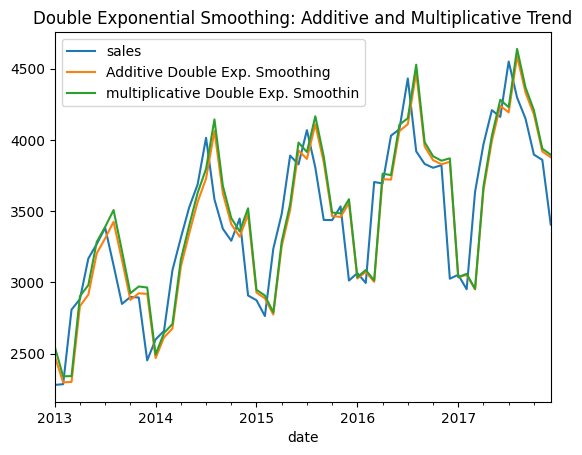

In [ ]:
# DOBLE SUAVIZADO EXPONENCIAL
HWES2_ADD = ExponentialSmoothing(df3,trend='add').fit()#.fittedvalues
HWES2_MUL = ExponentialSmoothing(df3,trend='mul').fit()#.fittedvalues
HWES2_ADD_fitted = HWES2_ADD.fittedvalues
HWES2_MUL_fitted = HWES2_MUL.fittedvalues
HWES2_ADD_fitted.name = 'Additive Double Exp. Smoothing'
HWES2_MUL_fitted.name = 'multiplicative Double Exp. Smoothin'
pd.concat([df3, HWES2_ADD_fitted, HWES2_MUL_fitted], axis=1).plot(title='Double Exponential Smoothing: Additive and Multiplicative Trend');

In [ ]:
# resultados a comparar
results["Double Exp. - Additive"] = [HWES2_ADD.sse] + [HWES2_ADD.aic] + [HWES2_ADD.bic]
results["Double Exp. - Multiplicative"] = [HWES2_MUL.sse] + [HWES2_MUL.aic] + [HWES2_MUL.bic]

In [ ]:
# COMPARACION DE MODELOS ADITIVO Y MULTIPLICATIVO
HWES2_MUL.summary()

Dep. Variable:,sales,No. Observations:,60
Model:,ExponentialSmoothing,SSE,6001729.185
Optimized:,True,AIC,698.793
Trend:,Multiplicative,BIC,707.170
Seasonal:,None,AICC,700.378
Seasonal Periods:,None,Date:,"Fri, 30 Jun 2023"
Box-Cox:,False,Time:,01:31:43
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.9950000,alpha,True
smoothing_trend,0.0473810,beta,True


**APARENTEMENTE EL MODELO DOBLE TIENE PEORES METRICAS DE BONDAD DE AJUSTE TANTO EN SSE Y AIC**

#TRIPLE SUAVIZADO EXPONENCIAL

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/holtwinters/model.py:83: RuntimeWarning: overflow encountered in matmul
  return err.T @ err


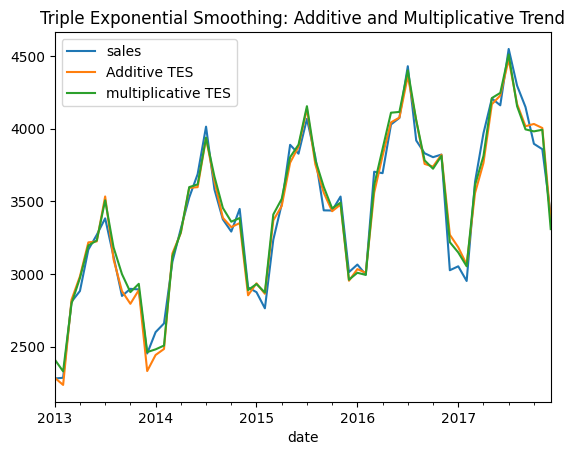

In [ ]:
# AJUSTE DEL MODELO
HWES3_ADD = ExponentialSmoothing(df3,trend='add',seasonal='add',seasonal_periods=12).fit()
HWES3_MUL = ExponentialSmoothing(df3,trend='mul',seasonal='mul',seasonal_periods=12).fit()

HWES3_ADD_fitted = HWES3_ADD.fittedvalues
HWES3_MUL_fitted = HWES3_MUL.fittedvalues
HWES3_ADD_fitted.name = 'Additive TES'
HWES3_MUL_fitted.name = 'multiplicative TES'
pd.concat([df3, HWES3_ADD_fitted, HWES3_MUL_fitted], axis=1).plot(title='Triple Exponential Smoothing: Additive and Multiplicative Trend');

In [ ]:
# DEFINIR MEDIDAS DE BONDAD DE AJUSTE
results["Triple Exp. - Additive"] = [HWES3_ADD.sse] + [HWES3_ADD.aic] + [HWES3_ADD.bic]
results["Triple Exp. - Multiplicative"] = [HWES3_MUL.sse] + [HWES3_MUL.aic] + [HWES3_MUL.bic]

In [ ]:
# RESULTADOS
results

,Simple Exponencial,Double Exp. - Additive,Double Exp. - Multiplicative,Triple Exp. - Additive,Triple Exp. - Multiplicative
SSE,5.528916e+06,5.697953e+06,6.001729e+06,533083.403604,493064.597375
AIC,6.898695e+02,6.956764e+02,6.987928e+02,577.525316,572.843055
BIC,6.940582e+02,7.040538e+02,7.071702e+02,611.034829,606.352568


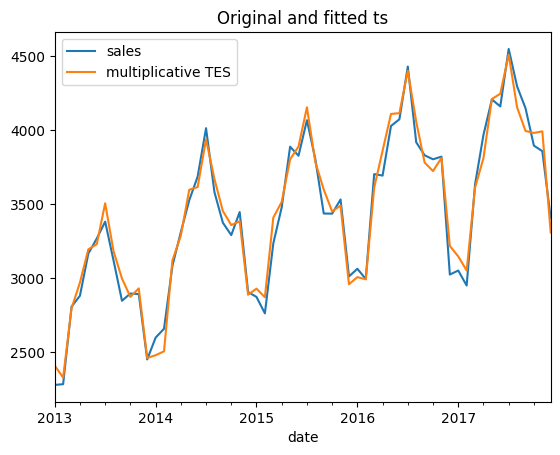

In [ ]:
# ajuste multiplicativo
pd.concat([df3, HWES3_MUL_fitted], axis=1).plot(title='Original and fitted ts');

In [ ]:
# RESUMEN DEL MODELO
HWES3_MUL.summary()

Dep. Variable:,sales,No. Observations:,60
Model:,ExponentialSmoothing,SSE,493064.597
Optimized:,True,AIC,572.843
Trend:,Multiplicative,BIC,606.353
Seasonal:,Multiplicative,AICC,589.526
Seasonal Periods:,12,Date:,"Fri, 30 Jun 2023"
Box-Cox:,False,Time:,01:53:29
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.4646429,alpha,True
smoothing_trend,0.0489098,beta,True


**APARENTEMENTE EL MEJOR MODELO ES EL MULTIPLICATIVO ADEMAS DE TENER EL VALOR MAS BAJO DE AIC**

# HOLT WINTERS

In [ ]:
fit1 = ExponentialSmoothing(
    df3,
    seasonal_periods=12,
    trend="add",
    seasonal="add",
    initialization_method="estimated",
).fit()

fit2 = ExponentialSmoothing(
    df3,
    seasonal_periods=12,
    trend="add",
    seasonal="mul",
    initialization_method="estimated",
).fit()

fit3 = ExponentialSmoothing(
    df3,
    seasonal_periods=12,
    trend="mul",
    seasonal="add",
    initialization_method="estimated",
).fit()

fit4 = ExponentialSmoothing(
    df3,
    seasonal_periods=12,
    trend="mul",
    seasonal="mul",
    initialization_method="estimated",
).fit()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/holtwinters/model.py:83: RuntimeWarning: overflow encountered in matmul
  return err.T @ err


In [ ]:
results2 = pd.DataFrame(
    index=["SSE", "AIC", "BIC"])

In [ ]:
results2["Holt Trend-Add Seas-Add"] = [fit1.sse] + [fit1.aic] + [fit1.bic]
results2["Holt Trend-Add Seas-Mul"] = [fit2.sse] + [fit2.aic] + [fit2.bic]
results2["Holt Trend-Mul Seas-Add"] = [fit3.sse] + [fit3.aic] + [fit3.bic]
results2["Holt Trend-Mul Seas-Mul"] = [fit4.sse] + [fit4.aic] + [fit4.bic]

In [ ]:
results2

,Holt Trend-Add Seas-Add,Holt Trend-Add Seas-Mul,Holt Trend-Mul Seas-Add,Holt Trend-Mul Seas-Mul
SSE,533083.403604,449274.963919,574359.332219,493064.597375
AIC,577.525316,567.262749,581.999956,572.843055
BIC,611.034829,600.772262,615.509469,606.352568


EL MEJOR MODELO SERIA EL HOLT WINTERS CON TENDENCIA ADITIVA Y ESTACINALIDAD MULTIPLICATIVA

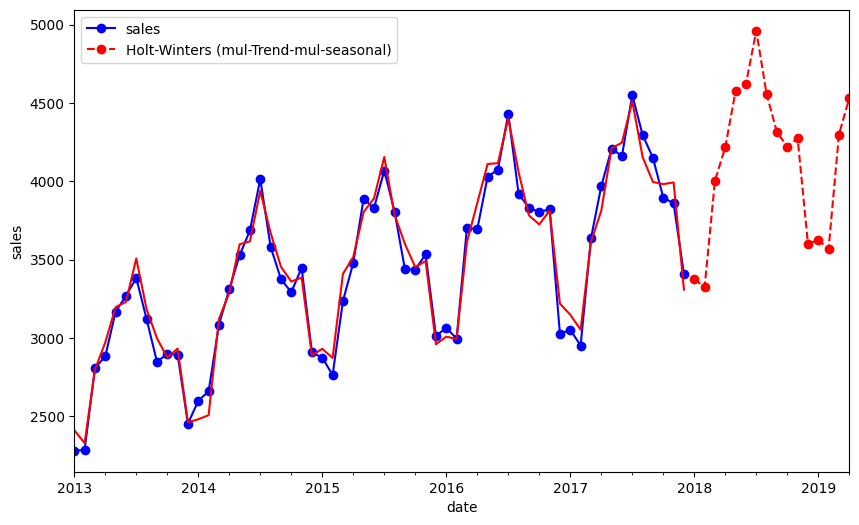

In [ ]:
ax = df3.plot(
    figsize=(10, 6),
    marker="o",
    color="blue",
)

ax.set_ylabel("sales")
ax.set_xlabel("Year")
fit4.fittedvalues.plot(ax=ax, style="-", color="red")
fit4.forecast(16).rename("Holt-Winters (mul-Trend-mul-seasonal)").plot(
    ax=ax, style="--", marker="o", color="red", legend=True
)

plt.show()

# MODELOS ARIMA

In [ ]:
 !pip install pmdarima

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 14.2 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore")
def fxn():
    warnings.warn("deprecated", DeprecationWarning)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fxn()


import itertools
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

import pandas as pd
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

import statsmodels as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

from math import sqrt

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['axes.labelsize'] = 14
matplotlib.rcParams['xtick.labelsize'] = 12
matplotlib.rcParams['ytick.labelsize'] = 12
matplotlib.rcParams['text.color'] = 'k'
import seaborn as sns

from random import random

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error, mean_squared_log_error

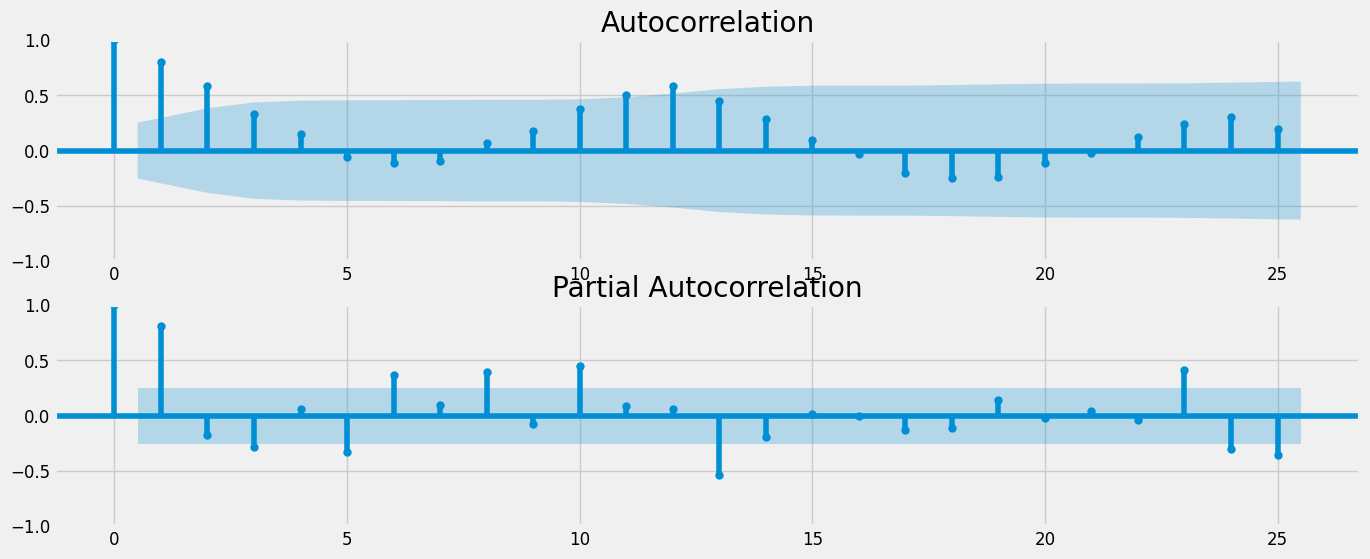

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(15,6))
plt.subplot(211)
plot_acf(df3.sales, ax=plt.gca(), lags = 25)
plt.subplot(212)
plot_pacf(df3.sales, ax=plt.gca(), lags = 25)
plt.show()

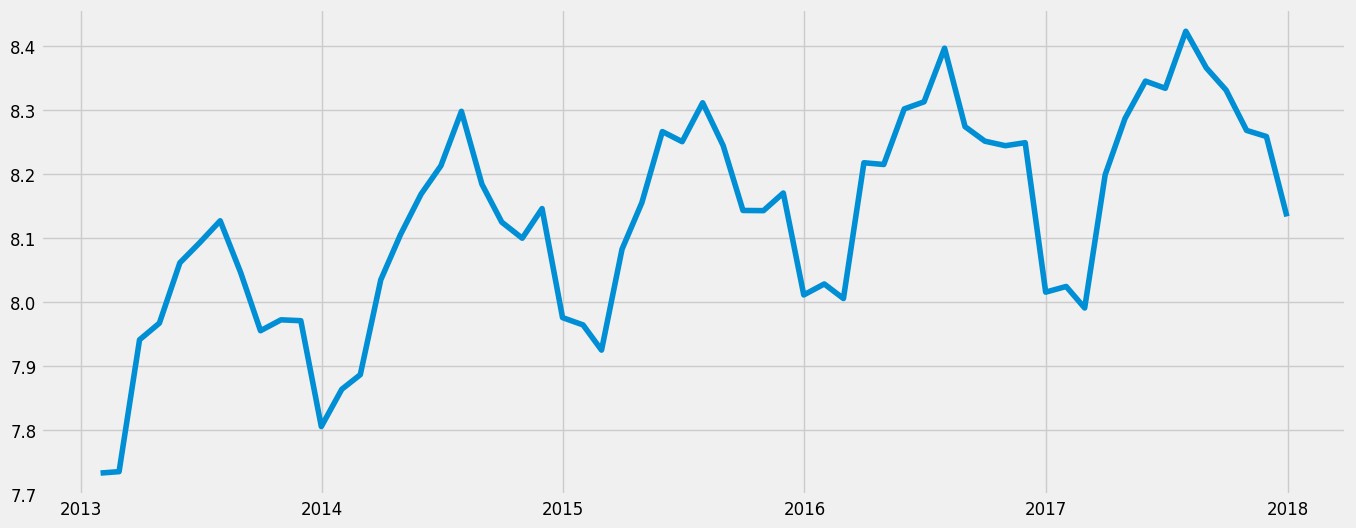

In [ ]:
# serie transformada logaritmica
ts_log = np.log(df3)
plt.figure(figsize=(15,6))
plt.plot(ts_log)
plt.show()

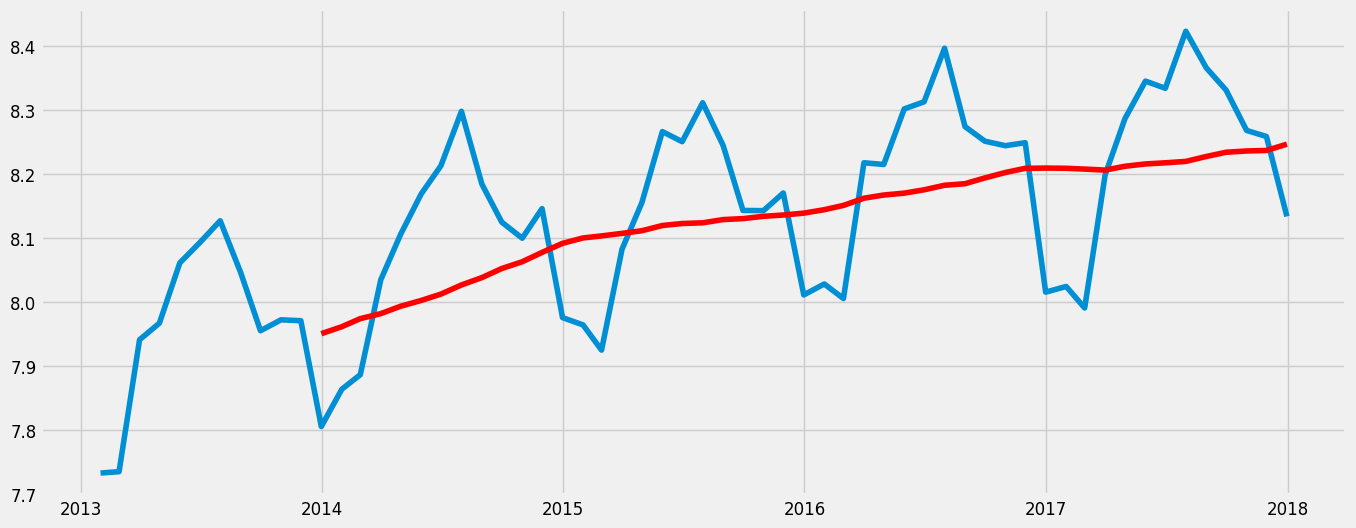

In [ ]:
# media movil
moving_avg = ts_log.rolling(12).mean()
plt.figure(figsize=(15,6))
plt.plot(ts_log)
plt.plot(moving_avg, color='red')
plt.show()

In [ ]:
ts_log_moving_avg_diff = ts_log.sales - moving_avg.sales
ts_log_moving_avg_diff.head(20)

date
2013-01-31         NaN
2013-02-28         NaN
2013-03-31         NaN
2013-04-30         NaN
2013-05-31         NaN
2013-06-30         NaN
2013-07-31         NaN
2013-08-31         NaN
2013-09-30         NaN
2013-10-31         NaN
2013-11-30         NaN
2013-12-31   -0.145038
2014-01-31   -0.097747
2014-02-28   -0.087559
2014-03-31    0.052857
2014-04-30    0.112297
2014-05-31    0.166247
2014-06-30    0.200585
2014-07-31    0.271308
2014-08-31    0.145934
Freq: M, Name: sales, dtype: float64

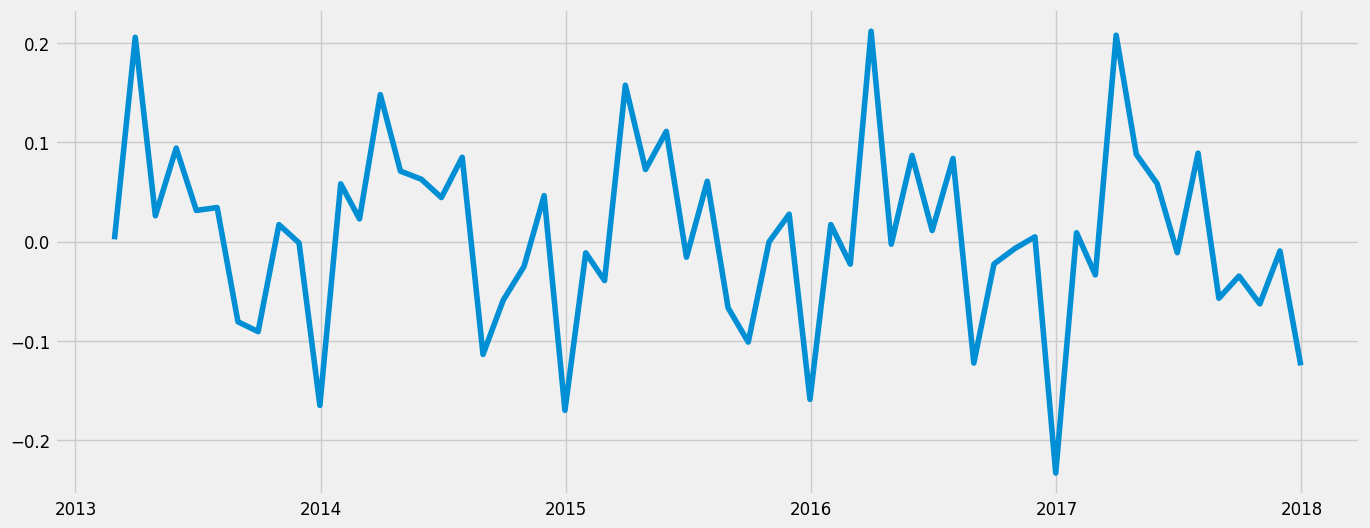

In [ ]:
# tranformacion por diferenciacion
ts_log_diff = ts_log.sales - ts_log.sales.shift()
plt.figure(figsize=(15,6))
plt.plot(ts_log_diff)
plt.show()

In [ ]:
# importando librerias
from statsmodels.tsa.ar_model import AutoReg, ar_select_order
from random import random

In [ ]:
# limpiar vacios
ts_log_diff = ts_log_diff.dropna()

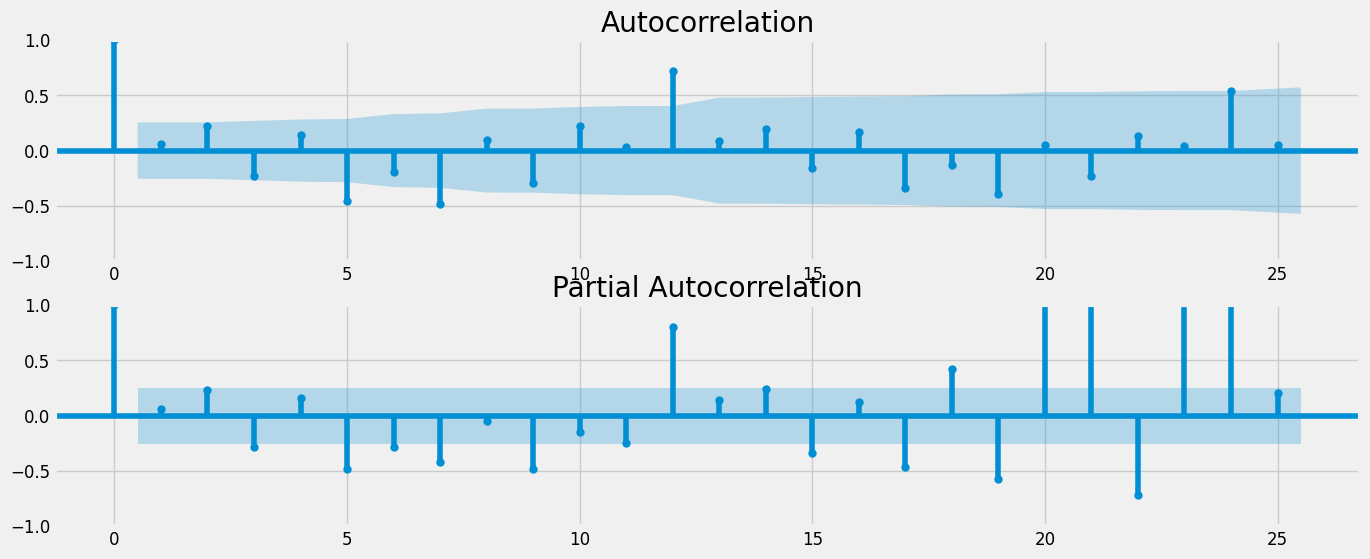

In [ ]:
# correlogramas
plt.figure(figsize=(15,6))
plt.subplot(211)
plot_acf(ts_log_diff, ax=plt.gca(), lags = 25)
plt.subplot(212)
plot_pacf(ts_log_diff, ax=plt.gca(), lags = 25)
plt.show()

In [ ]:
# ajustar modelo
model = AutoReg(ts_log_diff, 2, old_names=False)
model_fit = model.fit()
print(model_fit.summary())

                            AutoReg Model Results                             
Dep. Variable:                  sales   No. Observations:                   59
Model:                     AutoReg(2)   Log Likelihood                  58.690
Method:               Conditional MLE   S.D. of innovations              0.086
Date:                Sun, 02 Jul 2023   AIC                           -109.381
Time:                        19:40:00   BIC                           -101.209
Sample:                    04-30-2013   HQIC                          -106.205
                         - 12-31-2017                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.012      0.064      0.949      -0.022       0.023
sales.L1       0.0482      0.125      0.384      0.701      -0.198       0.294
sales.L2       0.2338      0.125      1.864      0.0

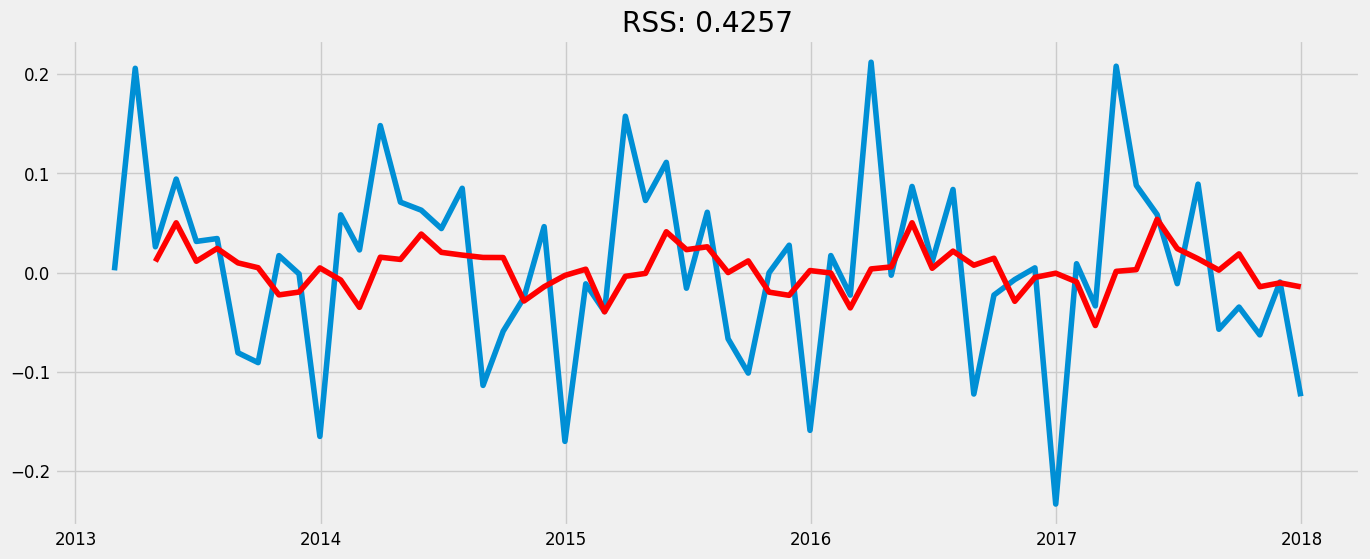

In [ ]:
# modelo ajustado
plt.figure(figsize=(15,6))
plt.plot(ts_log_diff)
plt.plot(model_fit.fittedvalues, color='red')
plt.title('RSS: %.4f'% np.nansum((model_fit.fittedvalues-ts_log_diff)**2))
plt.show()

In [ ]:
# valores predichos
predictions_ARIMA_diff = pd.Series(model_fit.fittedvalues, copy=True)
print (predictions_ARIMA_diff.head())

date
2013-04-30    0.011187
2013-05-31    0.050172
2013-06-30    0.011367
2013-07-31    0.024299
2013-08-31    0.009733
Freq: M, dtype: float64


In [ ]:
# suma acumulativa para destranformar
predictions_ARIMA_diff_cumsum = predictions_ARIMA_diff.cumsum()
print (predictions_ARIMA_diff_cumsum.head())

date
2013-04-30    0.011187
2013-05-31    0.061359
2013-06-30    0.072726
2013-07-31    0.097025
2013-08-31    0.106758
Freq: M, dtype: float64


In [ ]:
# agregar el valor retirado
predictions_ARIMA_log = pd.Series(ts_log.sales.iloc[0], index=ts_log.index)
predictions_ARIMA_log = predictions_ARIMA_log.add(predictions_ARIMA_diff_cumsum,fill_value=0)
predictions_ARIMA_log.head()

date
2013-01-31    7.732369
2013-02-28    7.732369
2013-03-31    7.732369
2013-04-30    7.743556
2013-05-31    7.793728
Freq: M, dtype: float64

In [ ]:
# tomando exponente para invertir el registro
predictions_ARIMA = np.exp(predictions_ARIMA_log)

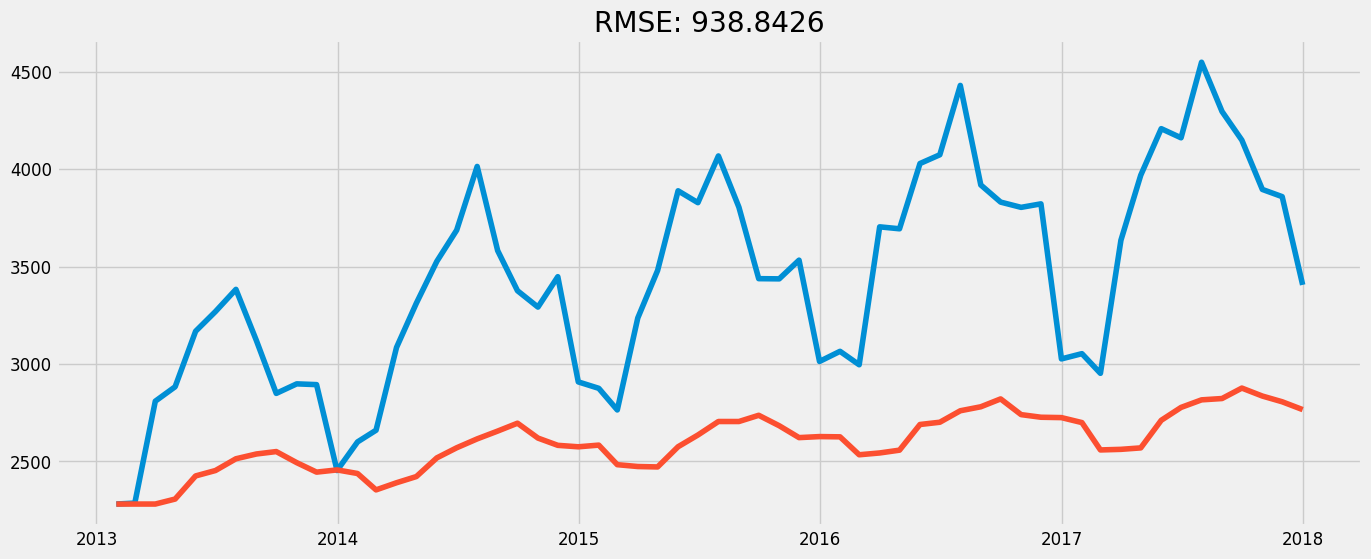

In [ ]:
# mal ajuste
plt.figure(figsize=(15,6))
plt.plot(df3.sales)
plt.plot(predictions_ARIMA)
plt.title('RMSE: %.4f'% np.sqrt(np.nansum((predictions_ARIMA-df3.sales)**2)/len(df3.sales)))
plt.show()

In [ ]:
# metricas de libreria
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error, mean_squared_log_error

In [ ]:
# MA example
from statsmodels.tsa.arima.model import ARIMA
from random import random

# fit model
model = ARIMA(ts_log_diff, order=(0, 0, 4))
model_fit = model.fit()

In [ ]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  sales   No. Observations:                   59
Model:                 ARIMA(0, 0, 4)   Log Likelihood                  62.747
Date:                Sun, 02 Jul 2023   AIC                           -113.493
Time:                        19:56:03   BIC                           -101.028
Sample:                    02-28-2013   HQIC                          -108.627
                         - 12-31-2017                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0074      0.024      0.302      0.763      -0.041       0.055
ma.L1          0.2261      0.146      1.551      0.121      -0.060       0.512
ma.L2          0.2749      0.205      1.340      0.180      -0.127       0.677
ma.L3         -0.0139      0.194     -0.072      0.943      -0.394       0.366
ma.L4          0.4286      0.163      2.629      0.009       0.109       0.748
sigma2         0.0069      0.001      5.429      0.000       0.004       0.009
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 0.05
Prob(Q):                              0.85   Prob(JB):                         0.98
Heteroskedasticity (H):               0.91   Skew:                             0.02
Prob(H) (two-sided):                  0.83   Kurtosis:                         3.13
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

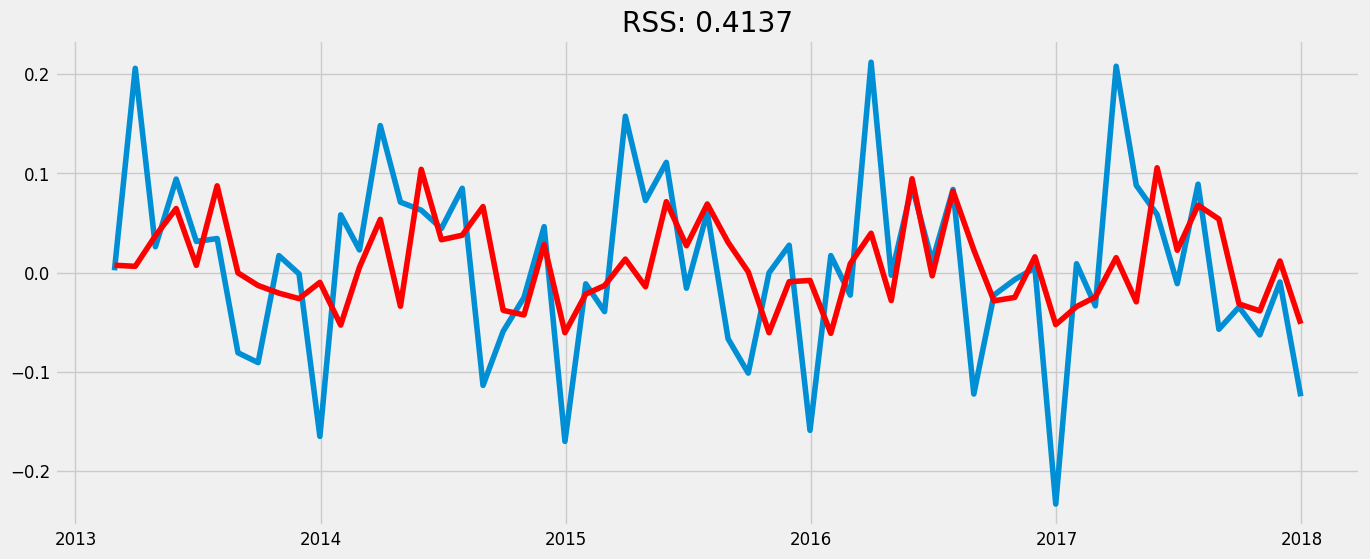

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(ts_log_diff)
plt.plot(model_fit.fittedvalues, color='red')
plt.title('RSS: %.4f'% np.nansum((model_fit.fittedvalues-ts_log_diff)**2))
plt.show()

In [ ]:
# ARMA example
from statsmodels.tsa.arima.model import ARIMA
from random import random

# fit model
model = ARIMA(ts_log_diff, order=(2,0,4))
model_fit = model.fit()

/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  sales   No. Observations:                   59
Model:                 ARIMA(2, 0, 4)   Log Likelihood                  72.103
Date:                Sun, 02 Jul 2023   AIC                           -128.206
Time:                        19:57:15   BIC                           -111.586
Sample:                    02-28-2013   HQIC                          -121.718
                         - 12-31-2017                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0053      0.005      1.064      0.287      -0.004       0.015
ar.L1         -0.4899      0.318     -1.539      0.124      -1.114       0.134
ar.L2          0.5045      0.313      1.611      0.107      -0.109       1.118
ma.L1          0.6852     77.117      0.009      0.993    -150.460     151.831
ma.L2         -0.7471    129.826     -0.006      0.995    -255.202     253.708
ma.L3         -0.7275     72.098     -0.010      0.992    -142.037     140.582
ma.L4         -0.2102     16.085     -0.013      0.990     -31.736      31.316
sigma2         0.0048      0.370      0.013      0.990      -0.720       0.730
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 1.41
Prob(Q):                              0.84   Prob(JB):                         0.49
Heteroskedasticity (H):               0.76   Skew:                            -0.30
Prob(H) (two-sided):                  0.55   Kurtosis:                         2.54
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

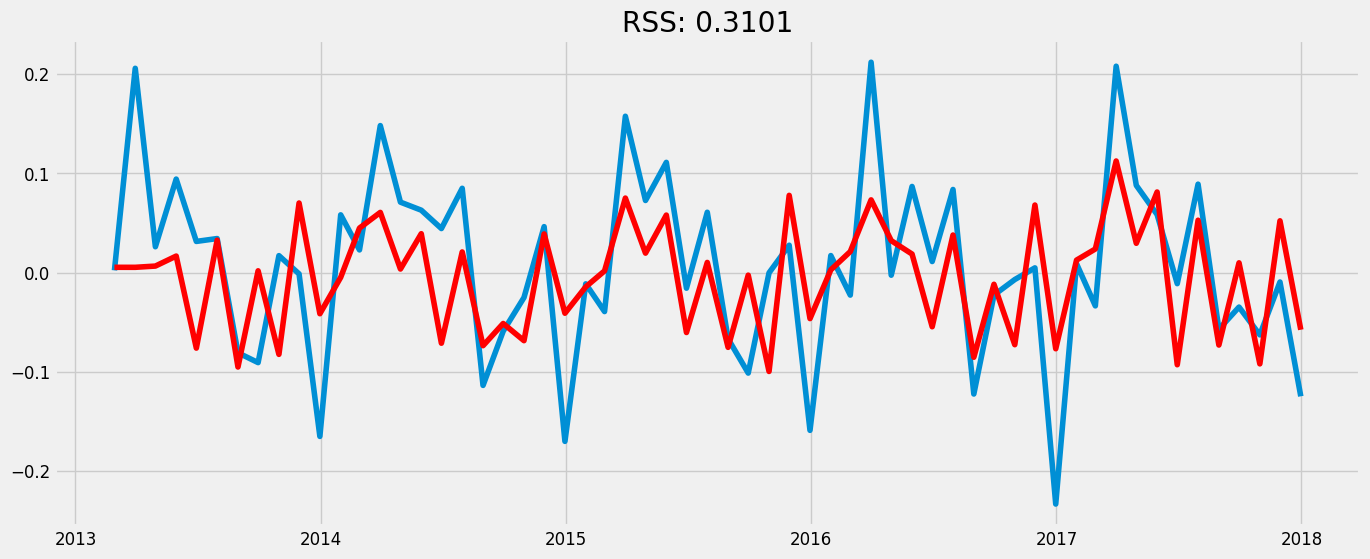

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(ts_log_diff)
plt.plot(model_fit.fittedvalues, color='red')
plt.title('RSS: %.4f'% np.nansum((model_fit.fittedvalues-ts_log_diff)**2))
plt.show()

In [ ]:
# EL MEJOR MODELO FUE EL HOLT WINTERS CON TENDENCIA ADITIVA Y ESTACINALIDAD MULTIPLICATIVA CON MENOR RMSE Y AIC(AKAIKE)